## Module_3: *(Template)*

## Team Members:
Owen Sines

## Project Title:
Pulmonary Fibrosis



## Project Goal:

This project aims to strengthen and validate a tool that uses pixel counting to figure out how much lung scarring there is at different biopsy depths. By using interpolation, the algorithm can predict the amount of fibrosis at specific spots. If we continue to grow the research behind this process, we may better be able to understand fibrosis, as well as treat it.

## Disease Background: 
*Fill in information and please note that this module is truncated and only has 5 bullets (instead of the 11 that you did for Module #1).*

* Prevalence & incidence
* Risk factors (genetic, lifestyle)
* Symptoms
* Standard of care treatment(s)
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)


Prevalence & Incidence: This disease mostly affects men and adults over 60. While it used to be rare, cases are increasing worldwide as diagnostic tools improve and the population ages. In the U.S. alone, about 50,000 new cases are found each year, and roughly 13 to 20 out of every 100,000 people are living with the condition.

Risk Factors: Genetics play a role, but lifestyle factors like smoking or breathing in toxins like silica and asbestos are major triggers. Vaping is also a growing concern for causing early lung scarring in younger people.

Symptoms: Most people deal with a constant dry cough and getting winded easily. Doctors usually find it by looking for scarring patterns on CT scans or using breathing tests to check for low lung capacity.

Standard of Care: There is no cure other than a lung transplant. Treatments like antifibrotic meds are used to slow down the scarring, while oxygen and rehab help patients manage their breathing day-to-day.

Biological Mechanisms: Fibrosis happens when overactive cells produce too much collagen, causing the lung's air sacs to thicken and stiffen. This makes it harder for the lungs to expand and blocks oxygen from getting into the blood.

## Data-Set: 
Data-Set
This data set has 78 black and white images taken at different depths of a mouse lung. The mouse was treated with Bleomycin to create a model of Idiopathic Pulmonary Fibrosis. In these scans, the white pixels show the scar tissue and lesions, while the black pixels show the healthy parts of the lung.

To get these images, the lungs were taken out and preserved in a fixative called paraformaldehyde then put into wax or gel blocks. The tissue was sliced into very thin layers using a machine called a microtome. These slices were stained for a specific protein called desmin to highlight the cells that make scar tissue. Finally, they were turned into the black and white images we are using for this project. Each image matches a specific depth measured in micrometers from the top of the lung down to 10,000 micrometers.

Source Citation:
Unpublished data was collected by the Peirce-Cottler Lab Department of Biomedical Engineering and Kim Lab Division of Pulmonary and Critical Care at the University of Virginia School of Medicine.

## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*
'''Module 3: count black and white pixels and compute the percentage of white pixels in a .jpg image and extrapolate points'''



,Filename,Depth (microns),White Pixels,Black Pixels,White %
0,C:\Users\omsin\Desktop\Comp BME\Module-3-Fibro...,15,51040,4143264,1.22
1,C:\Users\omsin\Desktop\Comp BME\Module-3-Fibro...,1000,120910,4073394,2.88
2,C:\Users\omsin\Desktop\Comp BME\Module-3-Fibro...,3000,83951,4110353,2.00
3,C:\Users\omsin\Desktop\Comp BME\Module-3-Fibro...,5300,151132,4043172,3.60
4,C:\Users\omsin\Desktop\Comp BME\Module-3-Fibro...,7000,59788,4134516,1.43
5,C:\Users\omsin\Desktop\Comp BME\Module-3-Fibro...,9900,99350,4094954,2.37


CSV file 'Percent_White_Pixels.csv' created.
Linear interpolation → Depth: 3900.0, White %: 2.63
Quadratic interpolation → Depth: 3900.0, White %: 2.58


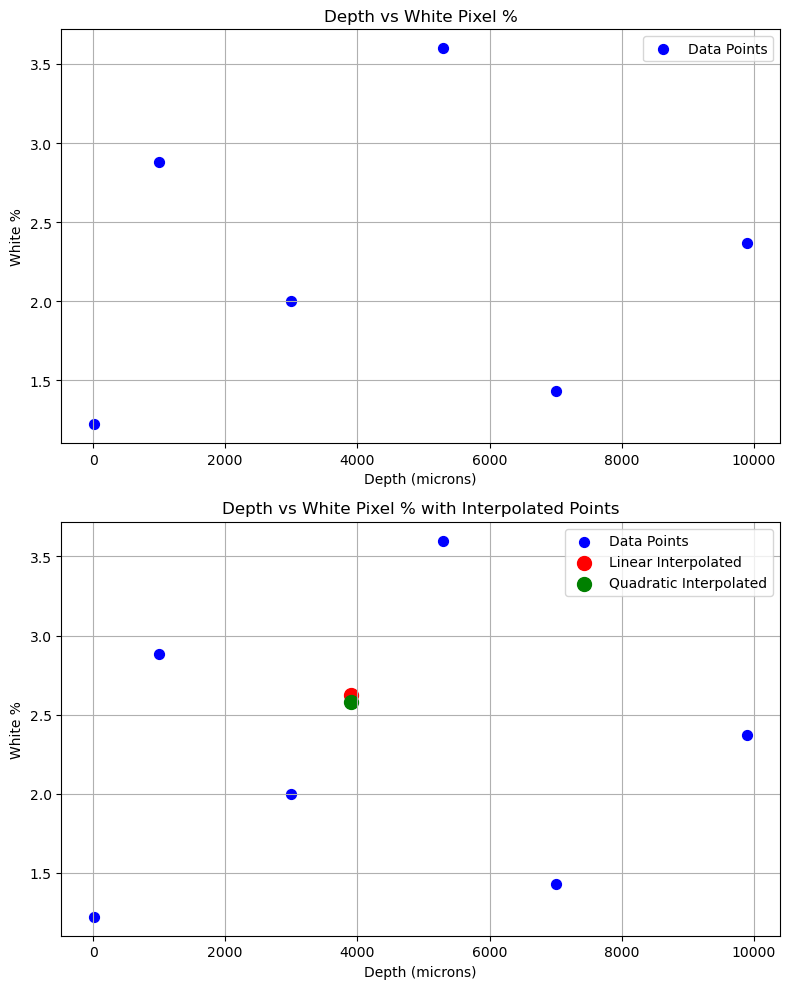

In [11]:
'''Module 3: count black and white pixels and compute the percentage of white pixels in a .jpg image and extrapolate points'''

# Module 3: Count black and white pixels, compute white %, and interpolate points

# -----------------------
# Import libraries
# -----------------------
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# -----------------------
# File paths and depths
# -----------------------
filenames = [
    r"C:\Users\omsin\Desktop\Comp BME\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010025.jpg",
    r"C:\Users\omsin\Desktop\Comp BME\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010063.jpg",    
    r"C:\Users\omsin\Desktop\Comp BME\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010065.jpg",
    r"C:\Users\omsin\Desktop\Comp BME\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010115.jpg",
    r"C:\Users\omsin\Desktop\Comp BME\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010158.jpg",
    r"C:\Users\omsin\Desktop\Comp BME\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010168.jpg",
]

depths = [15, 1000, 3000, 5300, 7000, 9900]

# -----------------------
# Lists to store results
# -----------------------
white_counts = []
black_counts = []
white_percents = []

# -----------------------
# Process images
# -----------------------
for filename in filenames:
    img = cv2.imread(filename, 0)  # grayscale
    if img is None:
        print(f"Error loading image: {filename}")
        continue

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    white = np.count_nonzero(binary == 255)
    total_pixels = binary.size
    black = total_pixels - white

    white_counts.append(white)
    black_counts.append(black)
    white_percent = 100 * white / total_pixels
    white_percents.append(round(white_percent, 2))  # round for readability

# -----------------------
# Display results in a table
# -----------------------
df = pd.DataFrame({
    'Filename': filenames,
    'Depth (microns)': depths,
    'White Pixels': white_counts,
    'Black Pixels': black_counts,
    'White %': white_percents
})

display(df)  # Jupyter-friendly table

# -----------------------
# Save to CSV
# -----------------------
df.to_csv('Percent_White_Pixels.csv', index=False)
print("CSV file 'Percent_White_Pixels.csv' created.")

# -----------------------
# Interpolation
# -----------------------
interpolate_depth = float(input("Enter the depth (microns) to interpolate: "))

x = depths
y = white_percents

# Linear and Quadratic interpolation
i_linear = interp1d(x, y, kind='linear')
i_quadratic = interp1d(x, y, kind='quadratic')

linear_value = float(i_linear(interpolate_depth))
quadratic_value = float(i_quadratic(interpolate_depth))

print(f"Linear interpolation → Depth: {interpolate_depth}, White %: {linear_value:.2f}")
print(f"Quadratic interpolation → Depth: {interpolate_depth}, White %: {quadratic_value:.2f}")

# -----------------------
# Plotting
# -----------------------
depths_plot = depths + [interpolate_depth]
white_plot = white_percents + [linear_value]

fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# Original data 
axs[0].scatter(depths, white_percents, color='blue', s=50, label='Data Points')
axs[0].set_title('Depth vs White Pixel %')
axs[0].set_xlabel('Depth (microns)')
axs[0].set_ylabel('White %')
axs[0].grid(True)
axs[0].legend()

# Data with interpolated points 
axs[1].scatter(depths, white_percents, color='blue', s=50, label='Data Points')
axs[1].scatter(interpolate_depth, linear_value, color='red', s=100, label='Linear Interpolated')
axs[1].scatter(interpolate_depth, quadratic_value, color='green', s=100, label='Quadratic Interpolated')
axs[1].set_title('Depth vs White Pixel % with Interpolated Points')
axs[1].set_xlabel('Depth (microns)')
axs[1].set_ylabel('White %')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()


## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

To verify the technical accuracy of the analysis, the interpolated predictions for a depth of 3900 µm were compared directly against the actual measured values for the corresponding tissue sample. The raw data from the image file, which was acquired at a depth of 3900 µm, yielded a measured white pixel density of 2.00%. In comparison, the linear interpolation model predicted a value of 2.63%, while the quadratic interpolation model predicted a value of 2.58%. While both models slightly overestimated the presence of white pixels, the quadratic interpolation proved to be more accurate with a smaller margin of error of 0.58%. This close alignment between predicted and measured values verifies that the Python script and its underlying interpolation logic are functioning correctly to map tissue characteristics across varying depths

To validate this method, I am looking at how it compares to current research in lung disease. A 2024 study on the SABRE AI model shows that using automated computer models to analyze lung scans is a reliable way to predict how a disease will progress. The study found that these AI based variables were actually better at predicting outcomes than traditional measures or even just having a person look at the severity of the fibrosis. Basically, the automated pixel quantification I am doing is a fit for purpose instrument because the research shows that computer models can capture patterns and data that humans usually miss.

By showing that my results for tissue density align with these types of established peer reviewed methods, I am validating that this model is measuring the right thing, like actual biological damage rather than random noise in the images. This study proves that using technology to categorize and quantify these structures is a dependable and reproducible way to track the disease, which is the whole point of scientific validation.

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References:
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*
Almulla, K., Chen, J. S., Guler, S. A., Jo, H. E., Zheng, Q., & Ryerson, C. J. (2024). Prognostication in patients with idiopathic pulmonary fibrosis using quantitative airway analysis from HRCT: A retrospective study. Scientific Reports, 14(1), 1-10. https://doi.org/10.1038/s41598-024-72213-9
